
📊 AVERAGING FEATURE VALUES FROM WINDOW FOLDERS
📂 Selected:
C:/Users/DELL/Documents/GitHub/fyp/05_Data_Storage/05_Features_/Raafiq(22-enc-05)v1_Features
📁 Output folder:
C:\Users\DELL\Documents\GitHub\fyp\05_Data_Storage\06_Averaged_Features\Raafiq(22-enc-05)v1_AveFeatures
✅ Found 12 windows
✅ Ensemble ratio column found: Ensemble ratio

📋 AVERAGED FEATURE TABLE


,Feature,RED,IR
0,Skewness,-0.335379,-0.354775
1,Kurtosis,-1.332786,-1.330464
2,Shannon Entropy,5.794352,5.800990
3,Spectral Entropy,1.557115,1.550353
4,pulse width,0.462967,0.466624
5,PPI,0.774012,0.774014
6,systolic amplitude,0.784633,0.799128
7,BPM,77.634791,77.632790
8,HRV,61.516886,60.864173
9,TEO Mean,0.000106,0.000110



📋 ENSEMBLE RATIO


,Feature,Value
0,Ensemble Ratio,0.794416


✅ Loaded 12 configuration file(s)
ℹ️ Detected flat feature JSON files instead of structured config JSON files


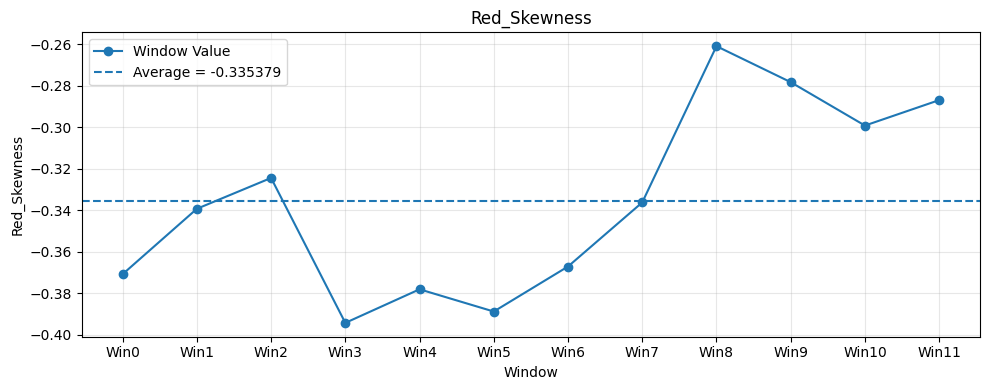

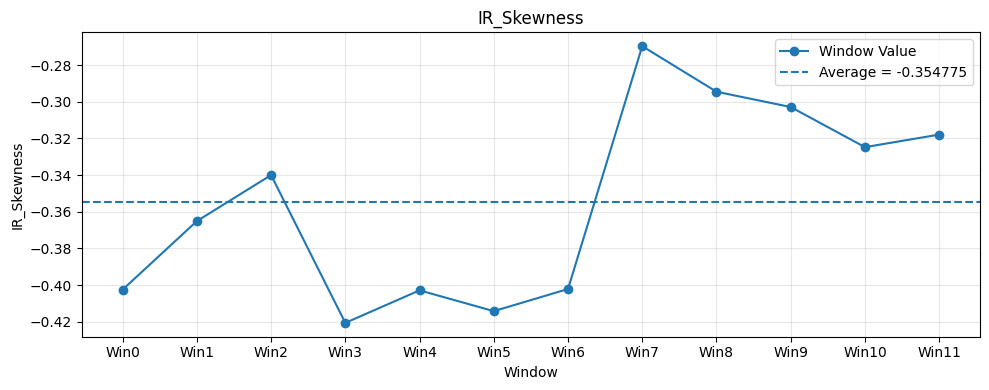

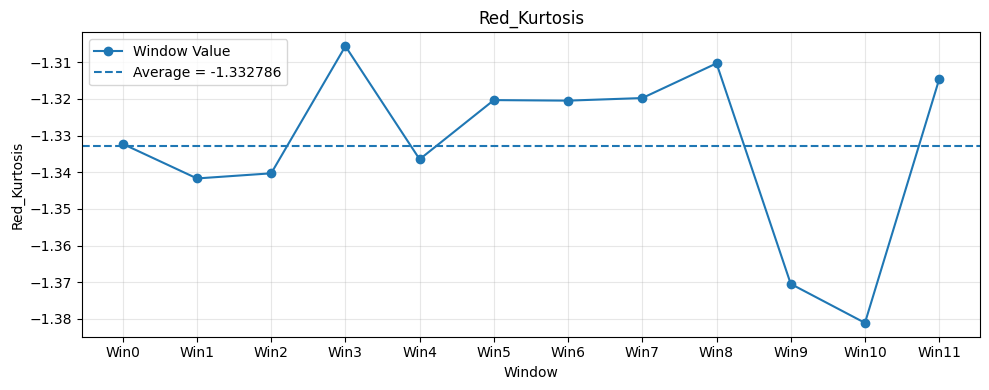

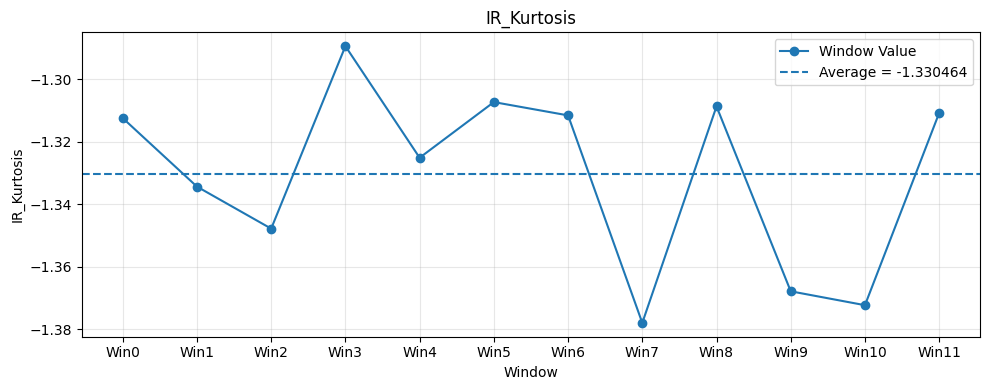

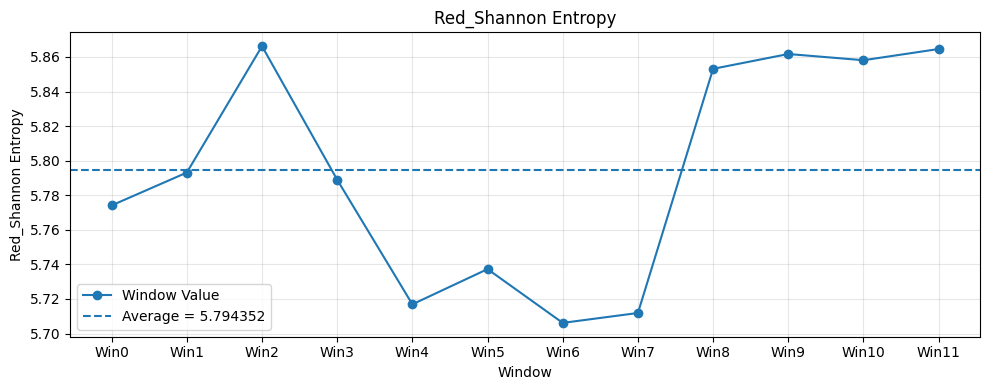

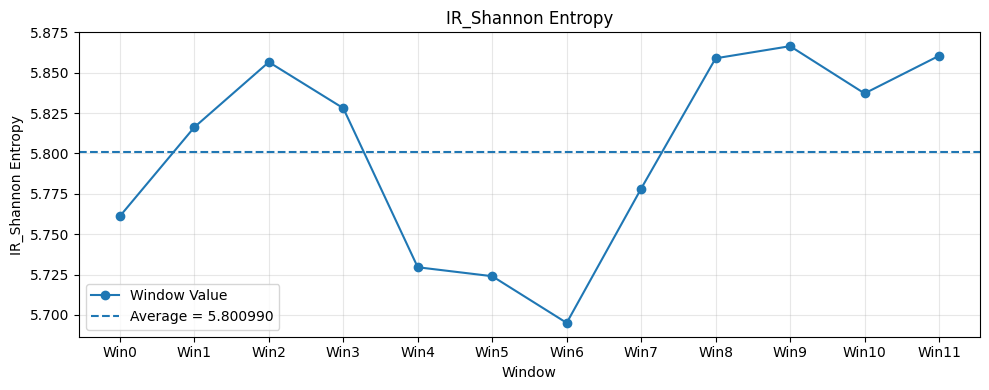

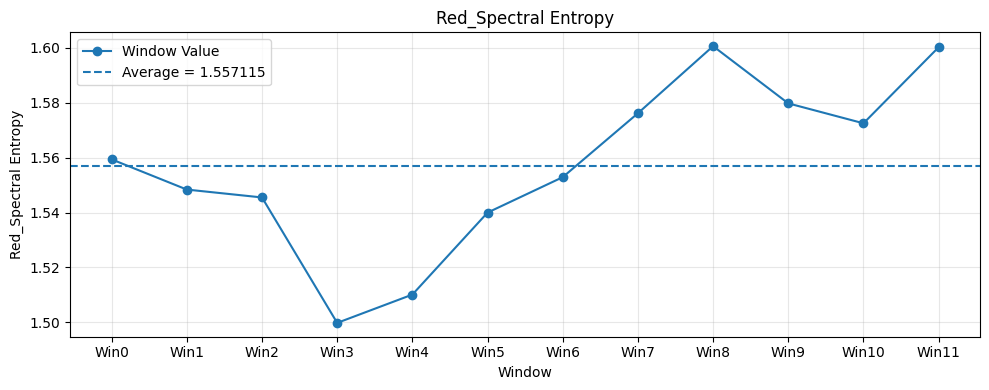

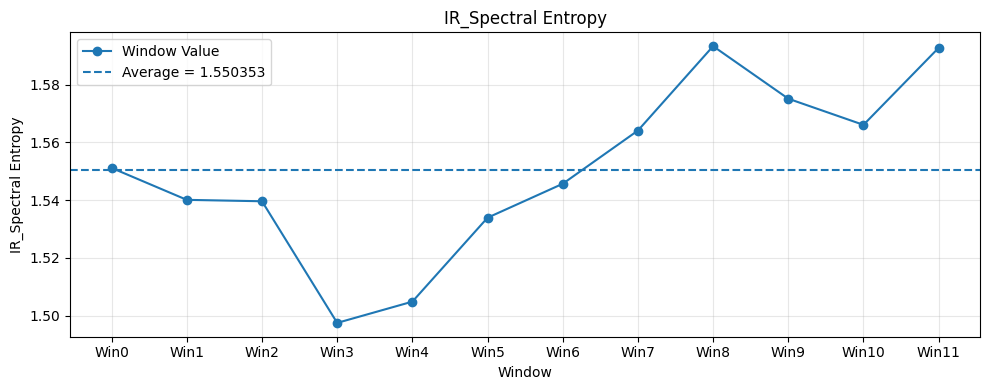

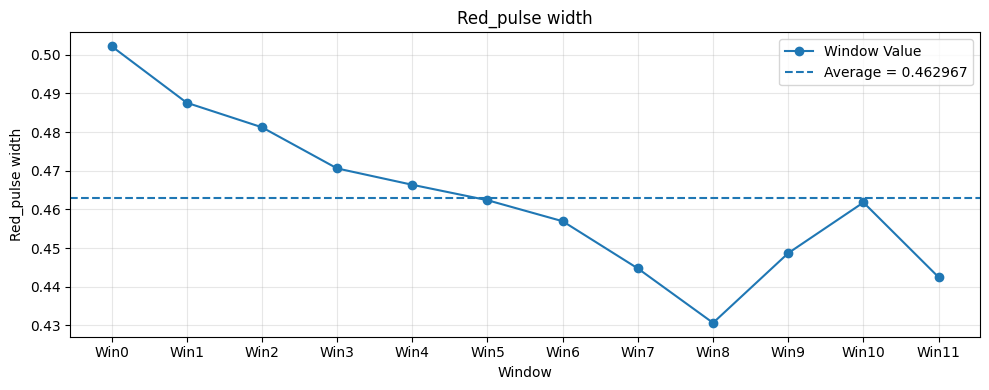

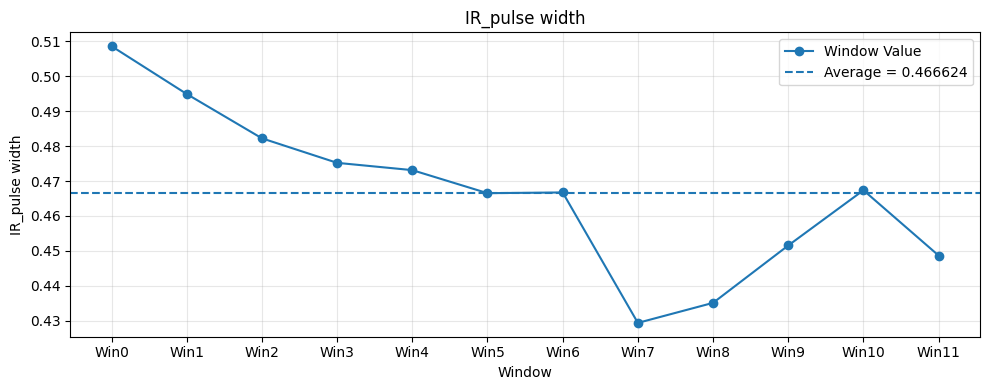

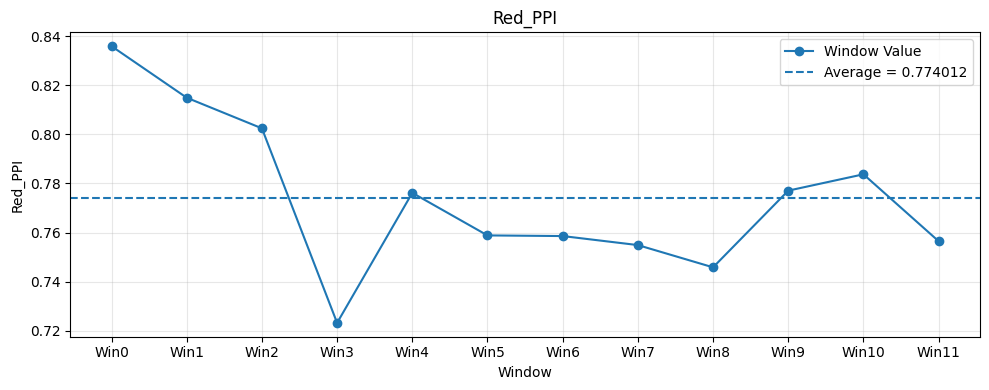

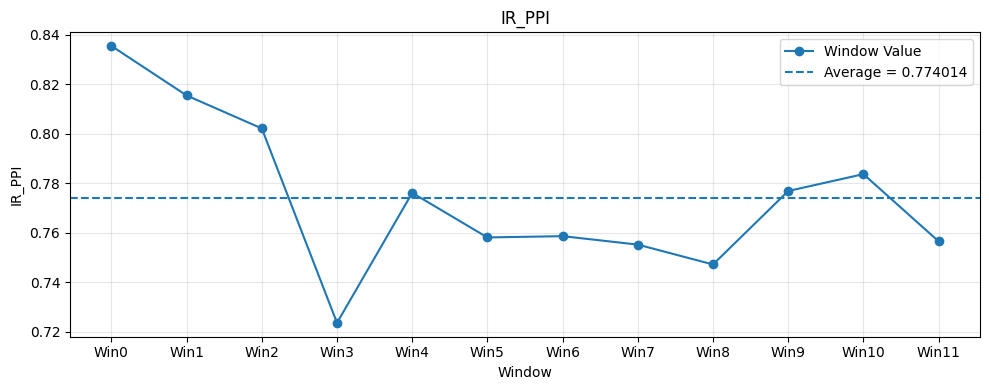

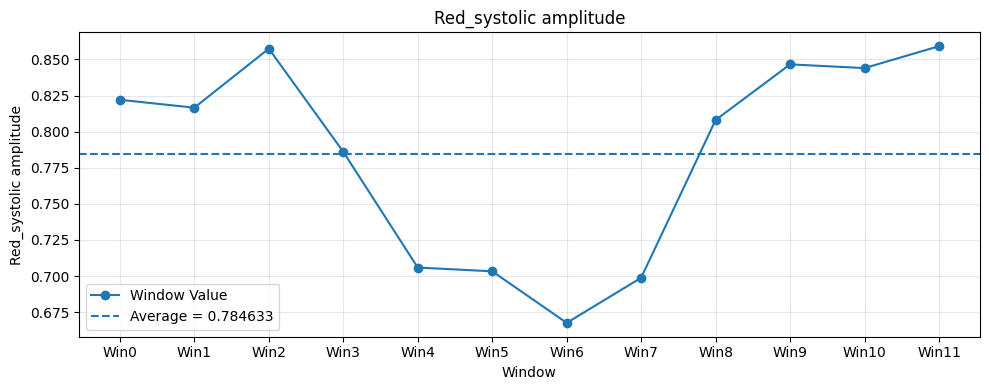

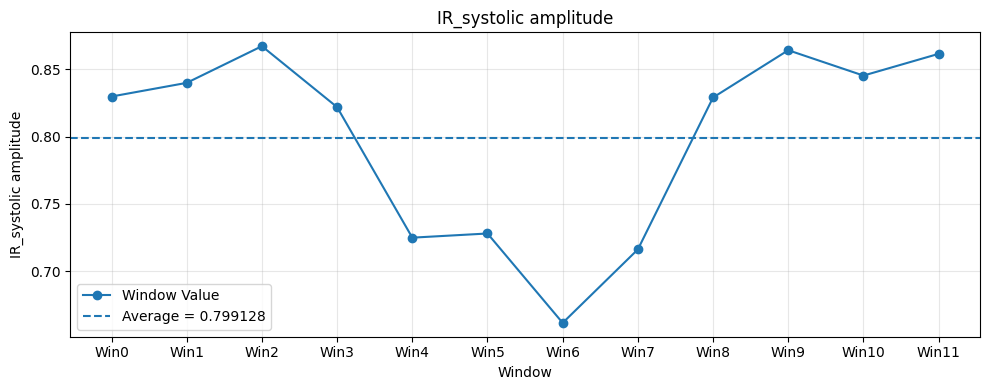

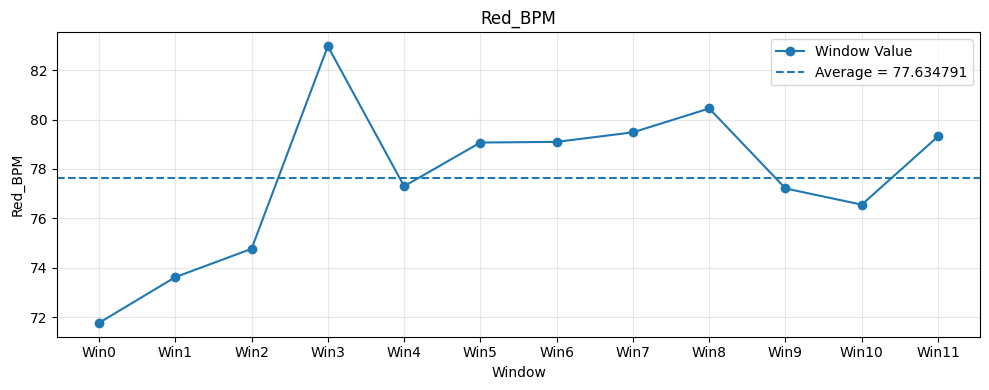

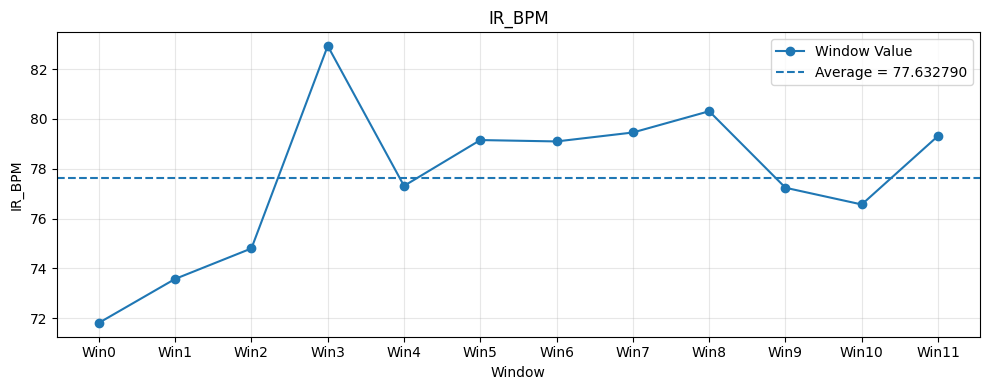

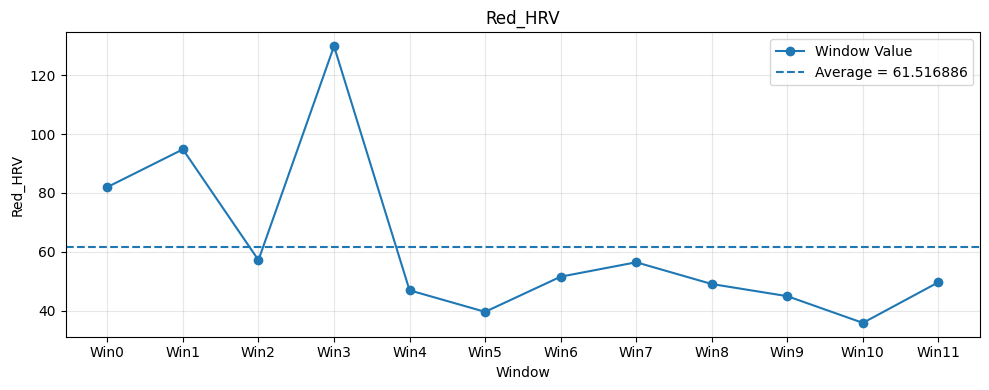

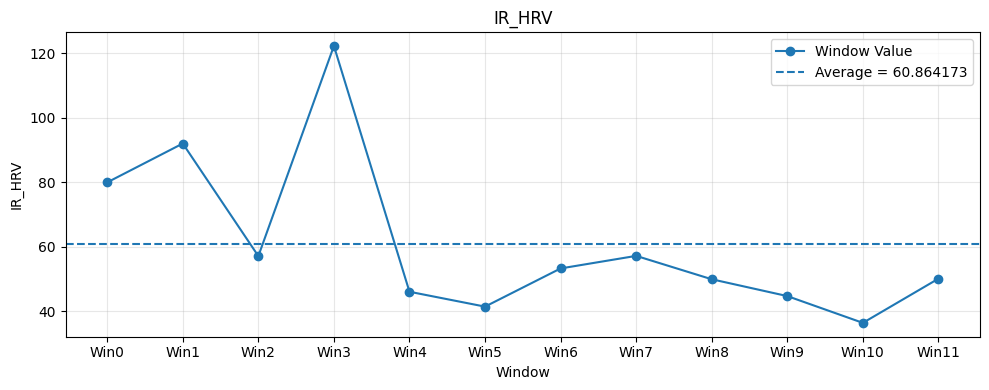

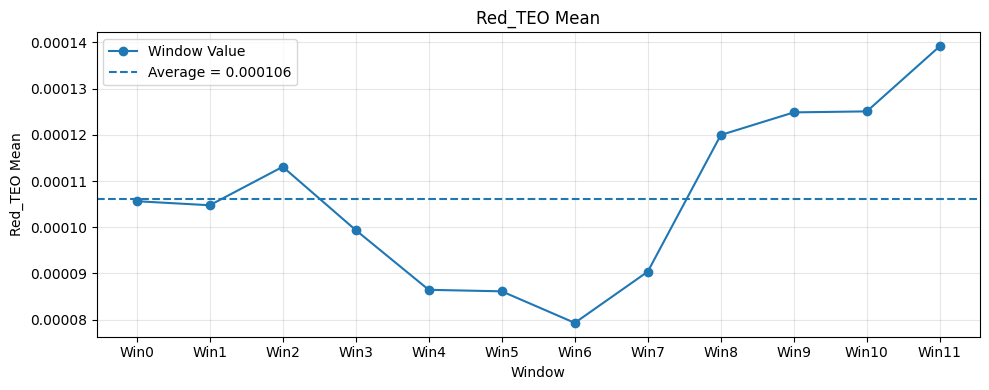

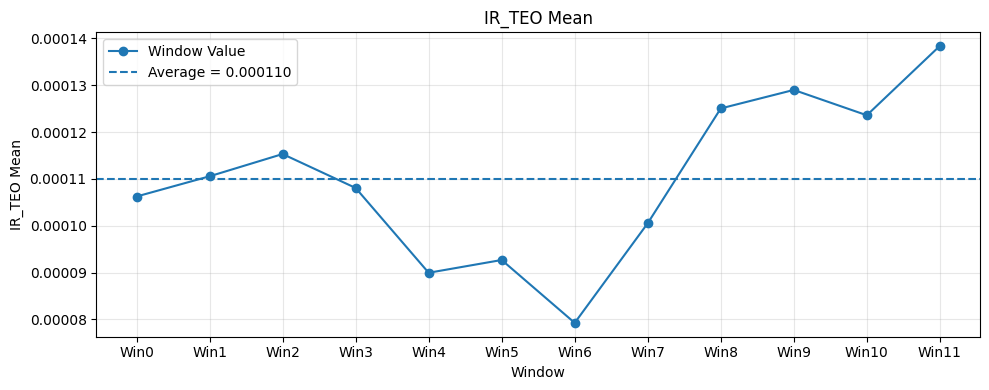

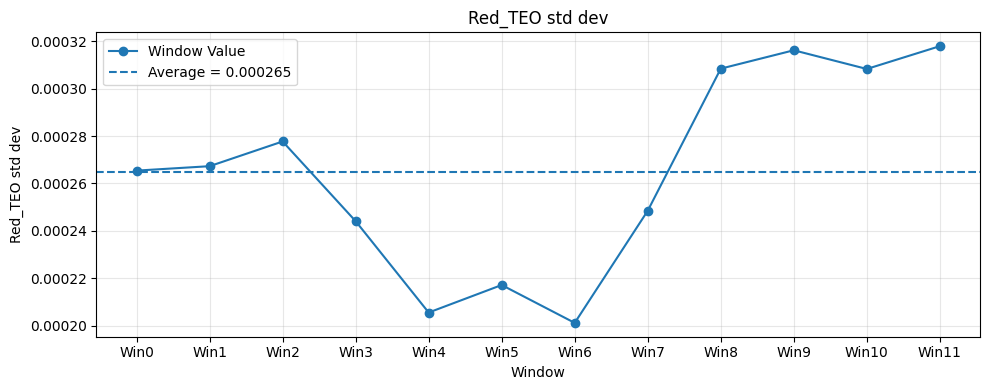

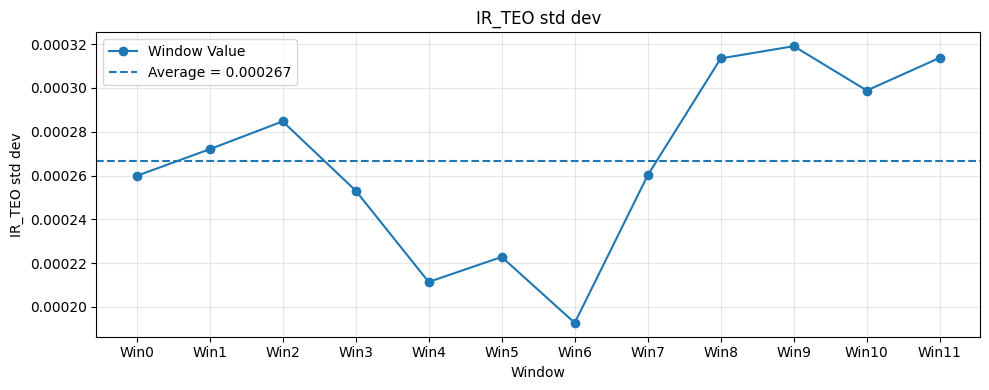

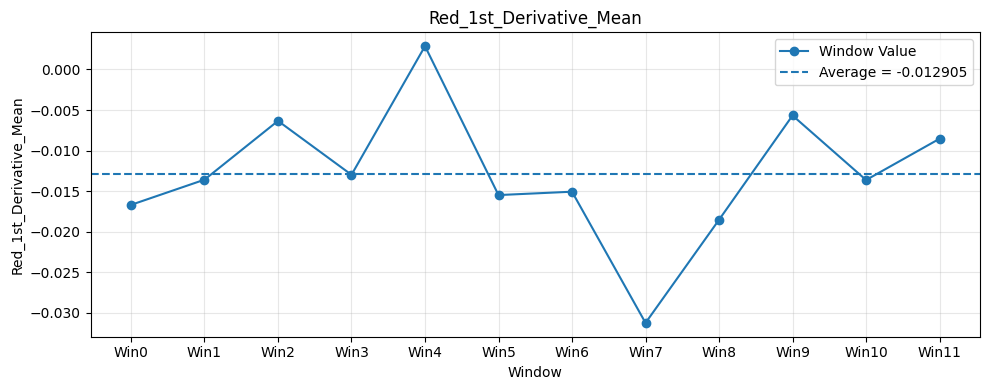

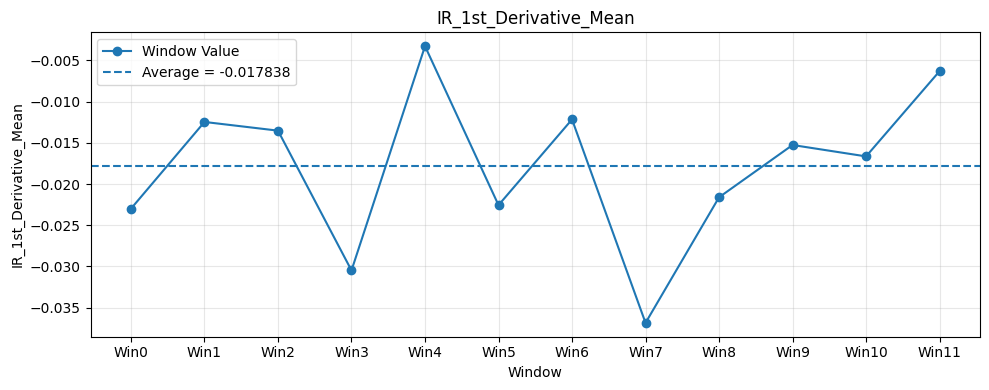

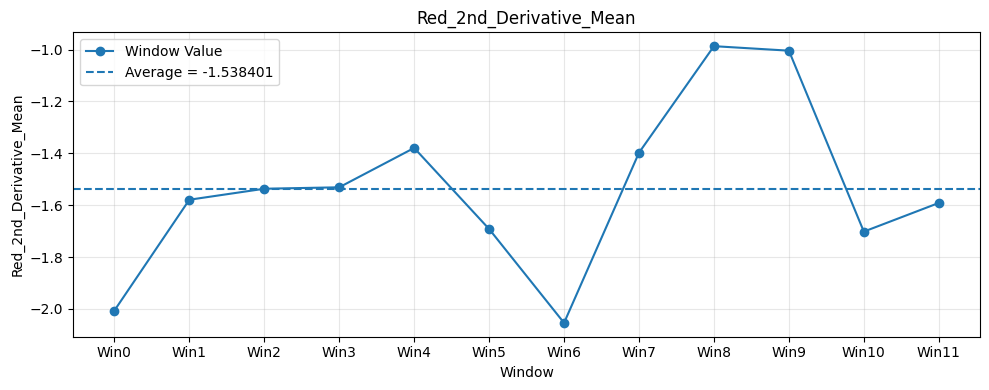

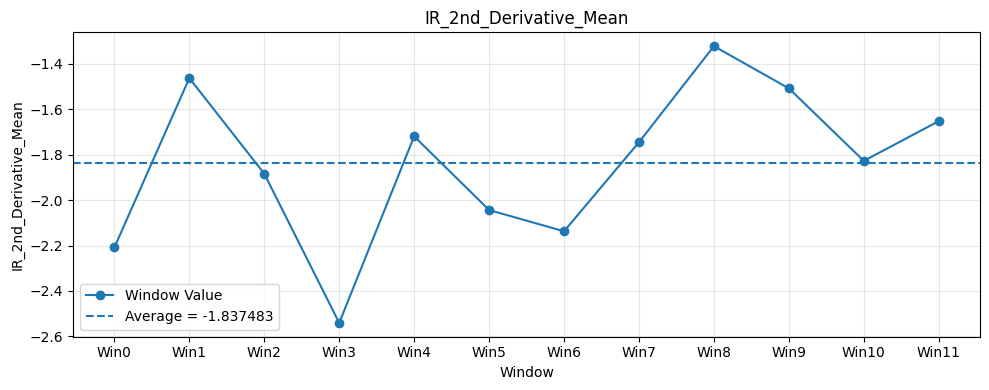

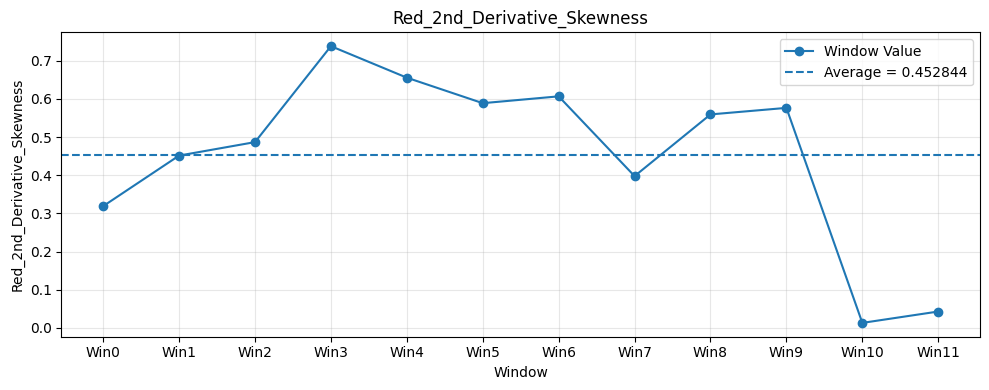

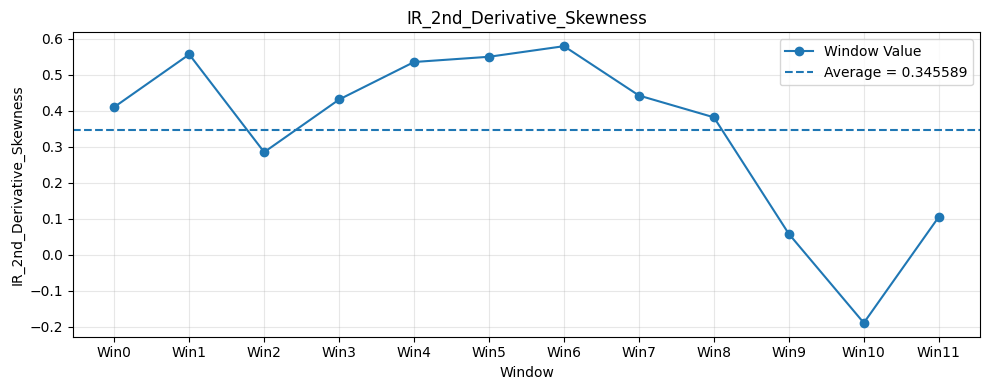

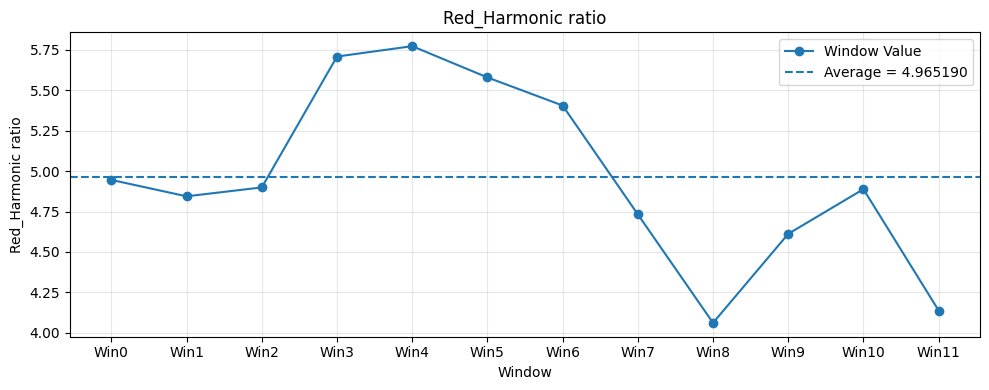

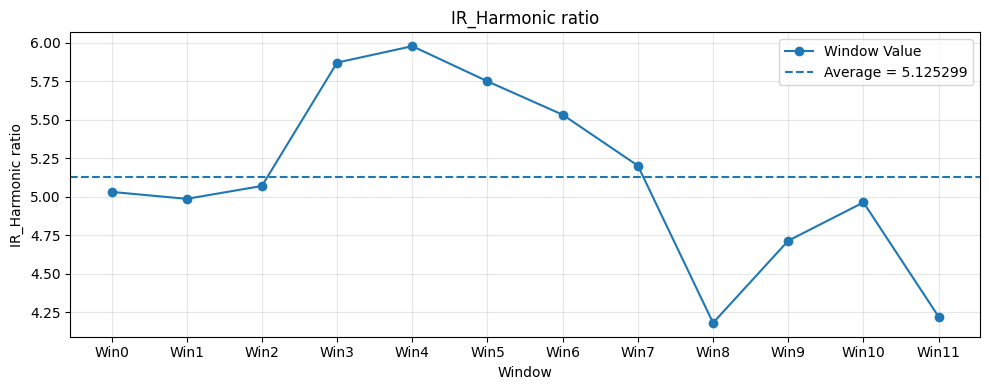

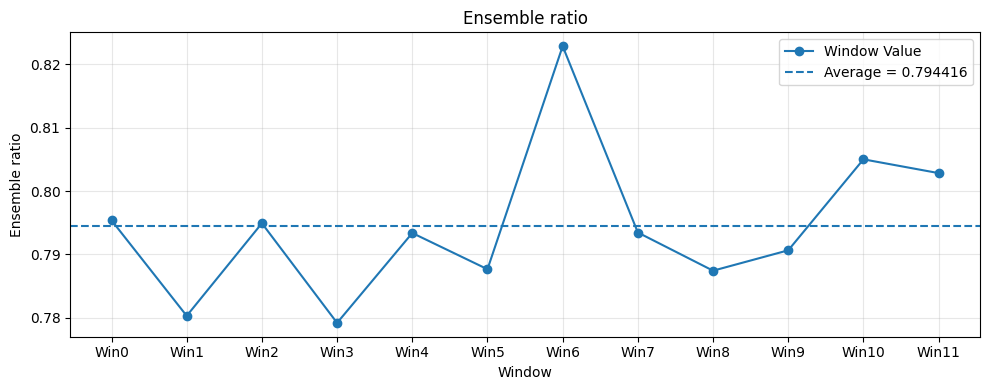

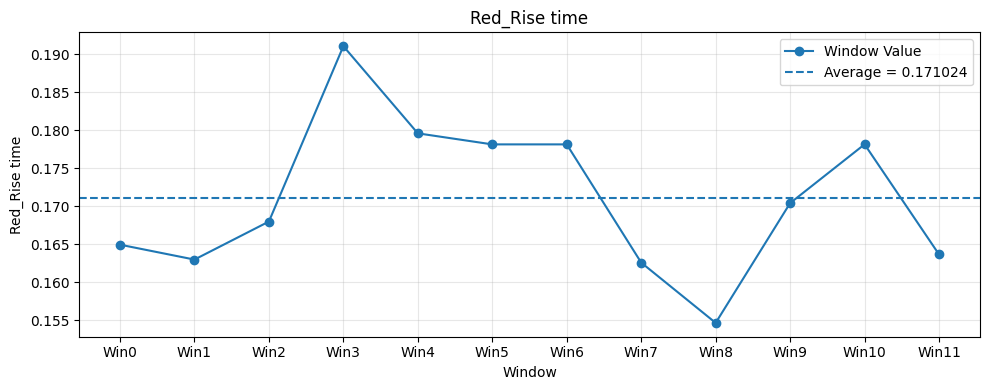

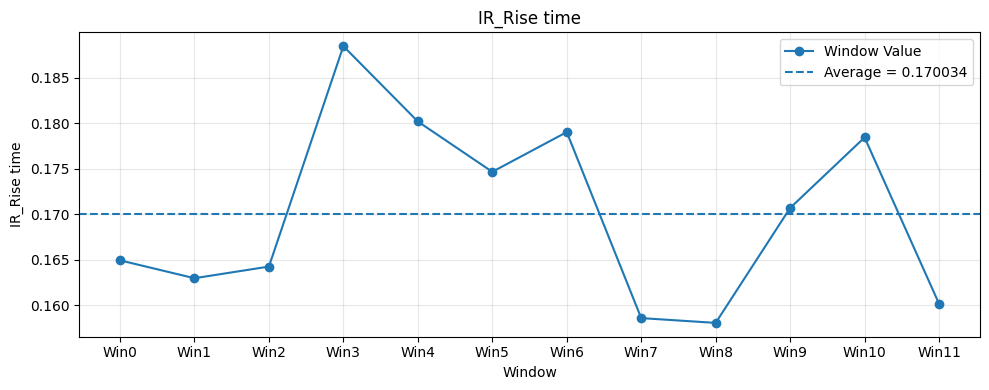

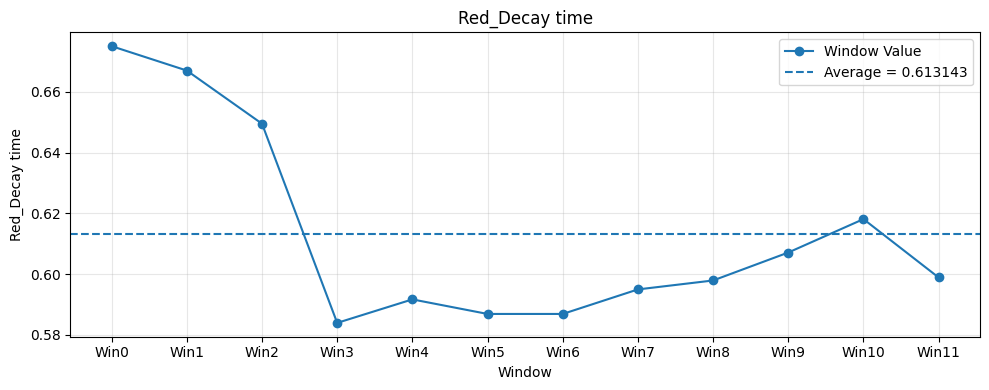

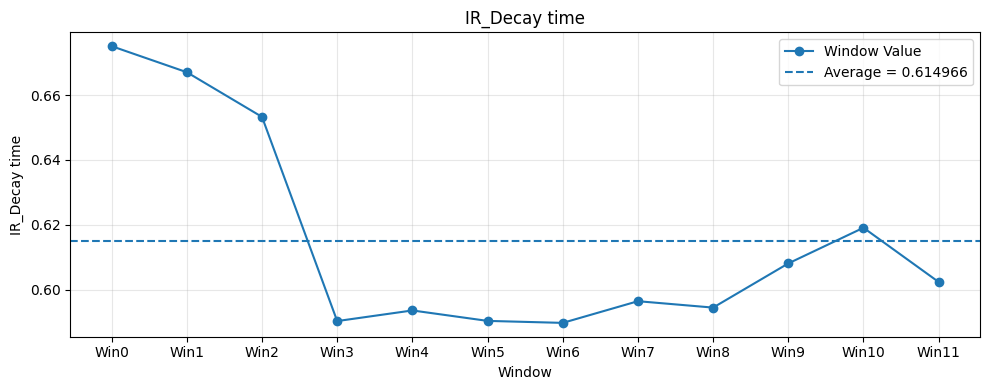

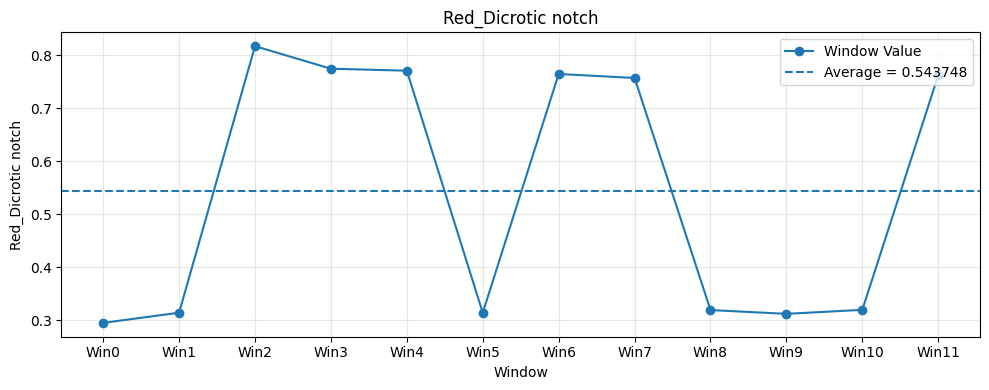

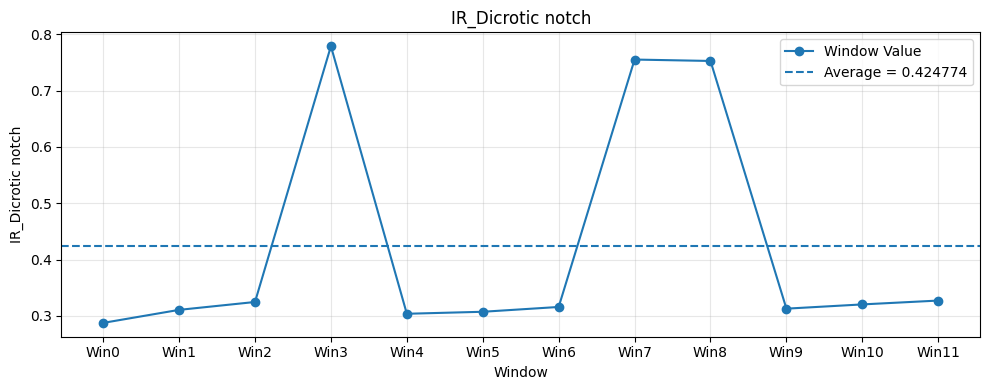


⚠️ CONFIRM SAVE


Output()

In [ ]:
import pandas as pd
import numpy as np
import os
import json
import tkinter as tk
from tkinter import filedialog
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from datetime import datetime

print("\n" + "=" * 60)
print("📊 AVERAGING FEATURE VALUES FROM WINDOW FOLDERS")
print("=" * 60)

# --------------------------------------------------
# PATHS
# --------------------------------------------------
input_root_path = r"C:\Users\DELL\Documents\GitHub\fyp\05_Data_Storage\05_Features_"
output_root = r"C:\Users\DELL\Documents\GitHub\fyp\05_Data_Storage\06_Averaged_Features"

if not os.path.exists(input_root_path):
    raise SystemExit("❌ Invalid input root path")

os.makedirs(output_root, exist_ok=True)

# --------------------------------------------------
# SELECT FEATURE FOLDER
# --------------------------------------------------
root = tk.Tk()
root.withdraw()
root.attributes("-topmost", True)

input_features_folder = filedialog.askdirectory(
    initialdir=input_root_path,
    title="Select the Features folder"
)

root.destroy()

if not input_features_folder:
    raise SystemExit("❌ No folder selected")

print(f"📂 Selected:\n{input_features_folder}")

# --------------------------------------------------
# OUTPUT PATH
# --------------------------------------------------
input_folder_name = os.path.basename(input_features_folder)

if input_folder_name.endswith("_Features"):
    base_name = input_folder_name[:-len("_Features")]
else:
    base_name = input_folder_name

output_folder_name = f"{base_name}_AveFeatures"
output_folder_path = os.path.join(output_root, output_folder_name)

output_csv_name = f"{base_name}_AveFeature.csv"
output_csv_path = os.path.join(output_folder_path, output_csv_name)

print(f"📁 Output folder:\n{output_folder_path}")

# --------------------------------------------------
# FIND WINDOW FOLDERS
# --------------------------------------------------
subfolders = [
    os.path.join(input_features_folder, f)
    for f in os.listdir(input_features_folder)
    if os.path.isdir(os.path.join(input_features_folder, f))
]

def get_win_index(name):
    if "_Win" in name:
        try:
            return int(name.split("_Win")[1].split("_")[0])
        except Exception:
            return 999
    return 999

subfolders = sorted(subfolders, key=lambda x: get_win_index(os.path.basename(x)))

print(f"✅ Found {len(subfolders)} windows")

# --------------------------------------------------
# LOAD FEATURES
# --------------------------------------------------
feature_rows = []
config_files = []
win_labels = []

for folder in subfolders:
    files = os.listdir(folder)

    flat = next((f for f in files if f.endswith("_Features_Flat.csv")), None)
    cfg = next((f for f in files if f.endswith("_Filtered_Configuration.json")), None)

    if flat is None:
        print(f"⚠️ Skipping folder (no flat feature CSV): {folder}")
        continue

    flat_path = os.path.join(folder, flat)

    try:
        df = pd.read_csv(flat_path)
    except Exception as e:
        print(f"⚠️ Failed to read feature CSV: {flat_path}\n   Reason: {e}")
        continue

    if df.empty:
        print(f"⚠️ Skipping empty feature CSV: {flat_path}")
        continue

    feature_rows.append(df.iloc[0])

    win_id = get_win_index(os.path.basename(folder))
    win_labels.append(f"Win{win_id}")

    if cfg:
        config_files.append(os.path.join(folder, cfg))
    else:
        print(f"⚠️ No config JSON found in: {folder}")

if len(feature_rows) == 0:
    raise SystemExit("❌ No valid feature rows found")

df_all = pd.DataFrame(feature_rows)

for col in df_all.columns:
    df_all[col] = pd.to_numeric(df_all[col], errors="coerce")

# --------------------------------------------------
# COMPUTE AVERAGE
# --------------------------------------------------
df_avg_flat = pd.DataFrame([df_all.mean(numeric_only=True)])

# --------------------------------------------------
# CREATE RED / IR TABLE (FIXED ROBUST VERSION)
# --------------------------------------------------
features = []
red_vals = []
ir_vals = []

for col in df_avg_flat.columns:

    # Skip ensemble ratio (handled separately)
    if col.strip().lower() == "ensemble ratio":
        continue

    # Process only Red features explicitly
    if col.startswith("Red_"):
        feature = col.replace("Red_", "")
        red_val = df_avg_flat[col].values[0]

        ir_col = "IR_" + feature

        if ir_col in df_avg_flat.columns:
            ir_val = df_avg_flat[ir_col].values[0]
        else:
            ir_val = np.nan

        features.append(feature)
        red_vals.append(red_val)
        ir_vals.append(ir_val)

df_table = pd.DataFrame({
    "Feature": features,
    "RED": red_vals,
    "IR": ir_vals
})

# --------------------------------------------------
# EXTRACT ENSEMBLE RATIO (FIXED)
# --------------------------------------------------
ratio_cols = [c for c in df_avg_flat.columns if c.strip().lower() == "ensemble ratio"]

if ratio_cols:
    ratio_col = ratio_cols[0]
    ratio_value = df_avg_flat[ratio_col].values[0]
    print(f"✅ Ensemble ratio column found: {ratio_col}")
else:
    ratio_value = np.nan
    print("⚠️ Ensemble ratio column not found")

df_ratio = pd.DataFrame({
    "Feature": ["Ensemble Ratio"],
    "Value": [ratio_value]
})

print("\n📋 AVERAGED FEATURE TABLE")
display(df_table)

print("\n📋 ENSEMBLE RATIO")
display(df_ratio)

# --------------------------------------------------
# SAFE JSON LOADING
# --------------------------------------------------
def load_json_safe(path):
    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception as e:
        print(f"⚠️ Failed to load JSON: {path}")
        print(f"   Reason: {e}")
        return None

def is_structured_config(cfg):
    if not isinstance(cfg, dict):
        return False
    return any(k in cfg for k in ["Metadata", "Processing_Settings", "Ensemble_Method"])

def is_flat_feature_json(cfg):
    if not isinstance(cfg, dict):
        return False
    keys = list(cfg.keys())
    return any(
        k.startswith("Red_") or
        k.startswith("IR_") or
        k.strip().lower() == "ensemble ratio"
        for k in keys
    )

# --------------------------------------------------
# SAFE CONFIG VALIDATION
# --------------------------------------------------
configs = []
valid_config_paths = []

for p in config_files:
    cfg = load_json_safe(p)
    if cfg is not None:
        configs.append(cfg)
        valid_config_paths.append(p)

sampling_rate = None
window_duration = None
ref_processing_settings = {}
ref_ensemble_method = {}
ref_metadata = {}
config_validation_notes = []
validation_status = "No configuration files loaded"

if len(configs) == 0:
    print("⚠️ No configuration files found or loaded successfully")
    ref = {}
else:
    ref = configs[0]
    print(f"✅ Loaded {len(configs)} configuration file(s)")

    if is_structured_config(ref):
        ref_processing_settings = ref.get("Processing_Settings", {})
        ref_ensemble_method = ref.get("Ensemble_Method", {})
        ref_metadata = ref.get("Metadata", {})

        if isinstance(ref_metadata, dict):
            sampling_rate = ref_metadata.get("Sampling_Rate_FS", None)
            window_duration = ref_metadata.get("Plot_Duration_Sec", None)

            if sampling_rate is None:
                print("⚠️ Warning: Reference config missing Metadata.Sampling_Rate_FS")
            if window_duration is None:
                print("⚠️ Warning: Reference config missing Metadata.Plot_Duration_Sec")
        else:
            print("⚠️ Warning: Reference config Metadata is invalid, using empty defaults")
            ref_metadata = {}

        for i, c in enumerate(configs[1:], start=1):
            label = f"config {i}"

            if not is_structured_config(c):
                msg = f"⚠️ {label} is not a structured config JSON"
                print(msg)
                config_validation_notes.append(msg)
                continue

            c_processing = c.get("Processing_Settings", {})
            c_ensemble = c.get("Ensemble_Method", {})
            c_metadata = c.get("Metadata", {})

            if ref_processing_settings and c_processing != ref_processing_settings:
                msg = f"⚠️ Processing_Settings mismatch in {label}"
                print(msg)
                config_validation_notes.append(msg)

            if ref_ensemble_method and c_ensemble != ref_ensemble_method:
                msg = f"⚠️ Ensemble_Method mismatch in {label}"
                print(msg)
                config_validation_notes.append(msg)

            c_fs = c_metadata.get("Sampling_Rate_FS", None) if isinstance(c_metadata, dict) else None
            c_dur = c_metadata.get("Plot_Duration_Sec", None) if isinstance(c_metadata, dict) else None

            if sampling_rate is not None and c_fs is not None and c_fs != sampling_rate:
                msg = f"⚠️ Sampling rate mismatch in {label}: {c_fs} != {sampling_rate}"
                print(msg)
                config_validation_notes.append(msg)

            if window_duration is not None and c_dur is not None and c_dur != window_duration:
                msg = f"⚠️ Window duration mismatch in {label}: {c_dur} != {window_duration}"
                print(msg)
                config_validation_notes.append(msg)

        if len(config_validation_notes) == 0:
            print("✅ Pipeline configuration checked successfully")
            validation_status = "No major configuration mismatches detected"
        else:
            print("⚠️ Configuration check completed with warnings")
            validation_status = "Warnings detected during configuration comparison"

    elif is_flat_feature_json(ref):
        print("ℹ️ Detected flat feature JSON files instead of structured config JSON files")
        validation_status = "Flat feature JSON detected; structured config validation skipped"

    else:
        print("⚠️ Unknown config JSON format")
        validation_status = "Unknown config format"

# --------------------------------------------------
# CREATE AVERAGED CONFIG JSON SAFELY
# --------------------------------------------------
average_config = {
    "Metadata": {
        "Base_Name": base_name,
        "Source_Features_Folder": input_features_folder,
        "Sampling_Rate_FS": sampling_rate,
        "Window_Duration_Sec": window_duration,
        "Number_of_Windows_Used": len(win_labels),
        "Date_Averaged": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    },
    "Processing_Settings": ref_processing_settings if isinstance(ref_processing_settings, dict) else {},
    "Ensemble_Method": ref_ensemble_method if isinstance(ref_ensemble_method, (dict, list, str, int, float, bool)) else {},
    "Averaging_Info": {
        "Averaging_Method": "Column-wise arithmetic mean",
        "Windows_Used": win_labels,
        "Configuration_Validation": validation_status,
        "Validation_Warnings": config_validation_notes
    }
}

# --------------------------------------------------
# PLOT FEATURES
# --------------------------------------------------
plots = {}

x = np.arange(len(win_labels))

for feat in df_all.columns:
    y = df_all[feat].values
    avg = np.nanmean(y)

    fig = plt.figure(figsize=(10, 4))

    plt.plot(x, y, marker="o", label="Window Value")
    plt.axhline(avg, linestyle="--", label=f"Average = {avg:.6f}")

    plt.xticks(x, win_labels)
    plt.xlabel("Window")
    plt.ylabel(feat)
    plt.title(feat)

    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plots[feat] = fig
    plt.show()

# --------------------------------------------------
# SAVE CONFIRMATION
# --------------------------------------------------
print("\n⚠️ CONFIRM SAVE")

out = widgets.Output()

btn_save = widgets.Button(description="✅ Save Files", button_style="success")
btn_cancel = widgets.Button(description="❌ Cancel", button_style="danger")

box = widgets.HBox([btn_save, btn_cancel])

def do_save():
    os.makedirs(output_folder_path, exist_ok=True)

    df_avg_flat.to_csv(output_csv_path, index=False)

    config_path = os.path.join(output_folder_path, f"{base_name}_AveFeature_Config.json")

    with open(config_path, "w", encoding="utf-8") as f:
        json.dump(average_config, f, indent=4)

    plot_dir = os.path.join(output_folder_path, "Feature_Plots")
    os.makedirs(plot_dir, exist_ok=True)

    for feat, fig in plots.items():
        safe = "".join(c if c.isalnum() else "_" for c in feat)

        fig.savefig(
            os.path.join(plot_dir, f"{safe}.png"),
            dpi=150,
            bbox_inches="tight"
        )

    print("🎉 Files saved successfully")
    print(f"📄 Averaged CSV: {output_csv_path}")
    print(f"🧾 Config JSON: {config_path}")
    print(f"🖼️ Plot folder: {plot_dir}")

def on_save(_):
    btn_save.disabled = True
    btn_cancel.disabled = True

    with out:
        clear_output(wait=True)
        print("💾 Saving...")
        do_save()

def on_cancel(_):
    btn_save.disabled = True
    btn_cancel.disabled = True

    with out:
        clear_output(wait=True)
        print("❌ Save cancelled")

btn_save.on_click(on_save)
btn_cancel.on_click(on_cancel)

display(box, out)